HASIL KLASIFIKASI
Akurasi : 100.00%

Classification Report:
              precision    recall  f1-score   support

      Circle       1.00      1.00      1.00         5
   Rectangle       1.00      1.00      1.00         1
    Triangle       1.00      1.00      1.00         3

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



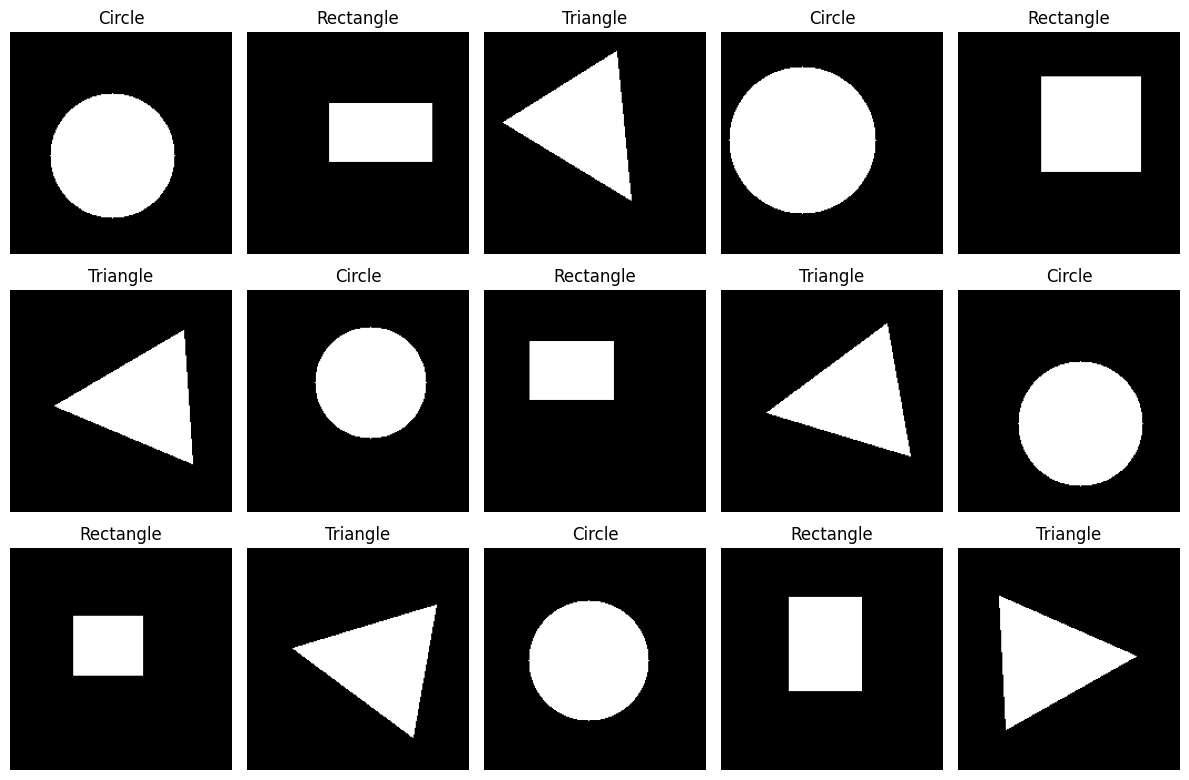

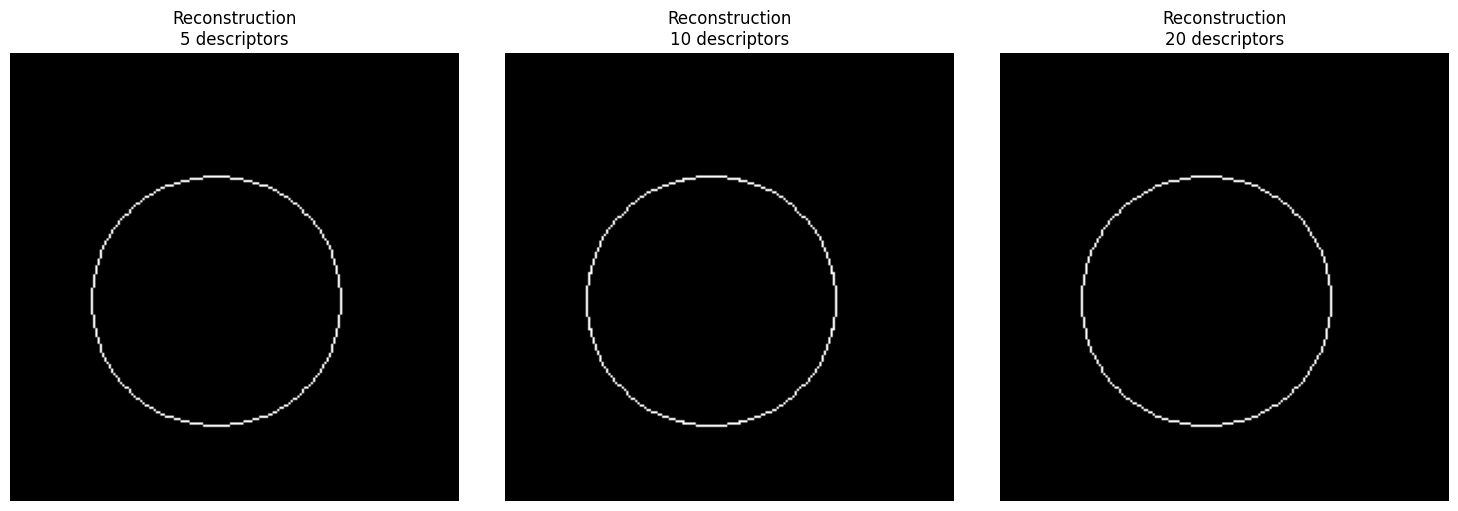

FITUR PALING DISKRIMINATIF

1. Hu Moments
   - Invariant terhadap rotasi, translasi, dan skala
   - Sangat baik membedakan bentuk

2. Fourier Descriptors
   - Representasi boundary paling stabil
   - Akurat untuk shape matching

3. Solidity & Aspect Ratio
   - Efektif membedakan rectangle, circle, triangle



In [3]:
# ============================================================
# SHAPE ANALYSIS PIPELINE UNTUK KLASIFIKASI OBJEK
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. MEMBUAT DATASET SEDERHANA
# ============================================================

dataset = []
labels = []

IMG_SIZE = 200

def create_circle():
    img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    radius = np.random.randint(40, 70)
    center = (
        np.random.randint(70, 130),
        np.random.randint(70, 130)
    )

    cv2.circle(img, center, radius, 255, -1)

    return img

def create_rectangle():
    img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    x1 = np.random.randint(40, 80)
    y1 = np.random.randint(40, 80)

    x2 = x1 + np.random.randint(60, 100)
    y2 = y1 + np.random.randint(40, 90)

    cv2.rectangle(img, (x1, y1), (x2, y2), 255, -1)

    return img

def create_triangle():
    img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    pts = np.array([
        [100, 40],
        [40, 160],
        [160, 160]
    ])

    angle = np.random.randint(0, 360)

    M = cv2.getRotationMatrix2D((100,100), angle, 1)

    pts_rot = cv2.transform(np.array([pts]), M)[0]

    cv2.fillPoly(img, [pts_rot.astype(np.int32)], 255)

    return img

# 10 sampel tiap kelas
for i in range(10):
    dataset.append(create_circle())
    labels.append("Circle")

    dataset.append(create_rectangle())
    labels.append("Rectangle")

    dataset.append(create_triangle())
    labels.append("Triangle")

# ============================================================
# 2. REGION PROPERTIES
# ============================================================

def extract_region_features(contour):

    area = cv2.contourArea(contour)

    perimeter = cv2.arcLength(contour, True)

    M = cv2.moments(contour)

    if M["m00"] != 0:
        cx = M["m10"] / M["m00"]
        cy = M["m01"] / M["m00"]
    else:
        cx, cy = 0, 0

    x, y, w, h = cv2.boundingRect(contour)

    hull = cv2.convexHull(contour)

    hull_area = cv2.contourArea(hull)

    aspect_ratio = float(w) / h

    rect_area = w * h

    extent = float(area) / rect_area

    solidity = float(area) / hull_area

    return [
        area,
        perimeter,
        cx,
        cy,
        aspect_ratio,
        extent,
        solidity
    ]

# ============================================================
# 3. MOMENTS FEATURES
# ============================================================

def extract_moments(contour):

    M = cv2.moments(contour)

    hu = cv2.HuMoments(M).flatten()

    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    features = [

        M["m00"],
        M["m10"],
        M["m01"],

        M["mu20"],
        M["mu02"],
        M["mu11"]
    ]

    features.extend(hu.tolist())

    return features

# ============================================================
# 4. CHAIN CODE
# ============================================================

directions_8 = [
    (1,0),
    (1,1),
    (0,1),
    (-1,1),
    (-1,0),
    (-1,-1),
    (0,-1),
    (1,-1)
]

def chain_code(contour):

    points = contour[:,0,:]

    code = []

    for i in range(len(points)-1):

        dx = points[i+1][0] - points[i][0]
        dy = points[i+1][1] - points[i][1]

        dx = np.sign(dx)
        dy = np.sign(dy)

        for idx, (x,y) in enumerate(directions_8):

            if dx == x and dy == y:
                code.append(idx)

    return code

def normalize_chain_code(code):

    if len(code) == 0:
        return []

    diff = []

    for i in range(len(code)):
        next_i = (i+1) % len(code)
        diff.append((code[next_i] - code[i]) % 8)

    return diff

# ============================================================
# 5. POLYGONAL APPROXIMATION
# ============================================================

def polygon_approx(contour):

    epsilon = 0.02 * cv2.arcLength(contour, True)

    approx = cv2.approxPolyDP(contour, epsilon, True)

    return len(approx)

# ============================================================
# 6. FOURIER DESCRIPTORS
# ============================================================

def fourier_descriptors(contour, n_descriptors=20):

    points = contour[:,0,:]

    complex_points = points[:,0] + 1j * points[:,1]

    fd = np.fft.fft(complex_points)

    fd = np.abs(fd)

    fd = fd / fd[0]

    return fd[:n_descriptors]

# ============================================================
# 7. EKSTRAKSI FITUR
# ============================================================

X = []

for img in dataset:

    contours, _ = cv2.findContours(
        img,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    contour = contours[0]

    # REGION FEATURES
    region_features = extract_region_features(contour)

    # MOMENTS
    moments_features = extract_moments(contour)

    # CHAIN CODE
    code = chain_code(contour)

    norm_code = normalize_chain_code(code)

    chain_features = [
        len(code),
        np.mean(norm_code),
        np.std(norm_code)
    ]

    # POLYGON
    polygon_features = [
        polygon_approx(contour)
    ]

    # FOURIER
    fd = fourier_descriptors(contour, 20)

    # GABUNG SEMUA FITUR
    features = (
        region_features +
        moments_features +
        chain_features +
        polygon_features +
        fd.tolist()
    )

    X.append(features)

X = np.array(X)
y = np.array(labels)

# ============================================================
# 8. NORMALISASI
# ============================================================

scaler = StandardScaler()

X = scaler.fit_transform(X)

# ============================================================
# 9. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# ============================================================
# 10. K-NN CLASSIFIER
# ============================================================

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# ============================================================
# 11. EVALUASI
# ============================================================

acc = accuracy_score(y_test, y_pred)

print("="*50)
print("HASIL KLASIFIKASI")
print("="*50)

print(f"Akurasi : {acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================================
# 12. VISUALISASI DATASET
# ============================================================

fig, axes = plt.subplots(3, 5, figsize=(12,8))

for i in range(15):

    axes[i//5, i%5].imshow(dataset[i], cmap='gray')

    axes[i//5, i%5].set_title(labels[i])

    axes[i//5, i%5].axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# 13. REKONSTRUKSI FOURIER
# ============================================================

sample_img = dataset[0]

contours, _ = cv2.findContours(
    sample_img,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

contour = contours[0]

points = contour[:,0,:]

complex_points = points[:,0] + 1j*points[:,1]

fd = np.fft.fft(complex_points)

fig, axes = plt.subplots(1,3, figsize=(15,5))

for idx, coeff in enumerate([5,10,20]):

    fd_copy = np.zeros_like(fd)

    fd_copy[:coeff] = fd[:coeff]
    fd_copy[-coeff:] = fd[-coeff:]

    recon = np.fft.ifft(fd_copy)

    x = np.real(recon)
    y = np.imag(recon)

    recon_img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    pts = np.column_stack([x,y]).astype(np.int32)

    cv2.polylines(
        recon_img,
        [pts],
        True,
        255,
        1
    )

    axes[idx].imshow(recon_img, cmap='gray')

    axes[idx].set_title(
        f"Reconstruction\n{coeff} descriptors"
    )

    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# 14. ANALISIS FITUR TERBAIK
# ============================================================

print("="*50)
print("FITUR PALING DISKRIMINATIF")
print("="*50)

print("""
1. Hu Moments
   - Invariant terhadap rotasi, translasi, dan skala
   - Sangat baik membedakan bentuk

2. Fourier Descriptors
   - Representasi boundary paling stabil
   - Akurat untuk shape matching

3. Solidity & Aspect Ratio
   - Efektif membedakan rectangle, circle, triangle
""")